# pymfx — Flight Statistics & Data Science

This notebook covers the analytical layer of `pymfx`:

1. **`flight_stats(mfx)`** — aggregated metrics with no extra dependencies
2. **`trajectory.to_dataframe()`** — pandas DataFrame with optional event merge
3. **`mfx.to_dict()` / `mfx.to_json()`** — full JSON serialisation

**Requirements:**
```bash
pip install pymfx[ds]   # adds pandas
```

In [1]:
import sys, math, uuid, json
sys.path.insert(0, '..')  # if running from notebooks/

import pymfx
from pymfx.models import (
    MfxFile, Meta, Trajectory, TrajectoryPoint, SchemaField,
    Events, Event, Index,
)
from pymfx import compute_checksum
from pymfx.stats import flight_stats

print(f"pymfx {pymfx.__version__}")

pymfx 1.0.0


## Build a demo mission (urban delivery flight)

In [2]:
BASE_LAT, BASE_LON = 48.8566, 2.3522   # Paris
N = 60
FREQ = 2.0  # Hz

raw_pts = [
    (
        round(i / FREQ, 3),
        round(BASE_LAT + i * 0.00012, 7),
        round(BASE_LON + math.sin(i * 0.18) * 0.0005, 7),
        round(80.0 + math.sin(i * 0.22) * 8, 2),
        round(7.5 + math.cos(i * 0.15) * 2, 2),
        round((i * 6) % 360, 1),
    )
    for i in range(N)
]

schema_fields = [
    SchemaField('t',        'float',   ['no_null']),
    SchemaField('lat',      'float',   ['no_null']),
    SchemaField('lon',      'float',   ['no_null']),
    SchemaField('alt_m',    'float32'),
    SchemaField('speed_ms', 'float32'),
    SchemaField('heading',  'float32'),
]

points    = [TrajectoryPoint(t=r[0], lat=r[1], lon=r[2], alt_m=r[3], speed_ms=r[4], heading=r[5]) for r in raw_pts]
raw_lines = [f"{r[0]:.3f} | {r[1]} | {r[2]} | {r[3]} | {r[4]} | {r[5]}" for r in raw_pts]

event_schema = [
    SchemaField('t',        'float', ['no_null']),
    SchemaField('type',     'str',   ['enum=[takeoff,landing,waypoint,anomaly,rtl]']),
    SchemaField('severity', 'str',   ['enum=[info,warning,critical]']),
    SchemaField('detail',   'str'),
]
event_list = [
    Event(t=0.0,  type='takeoff',  severity='info',    detail='depot_A'),
    Event(t=6.0,  type='waypoint', severity='info',    detail='wp1'),
    Event(t=12.5, type='anomaly',  severity='warning', detail='battery_90pct'),
    Event(t=18.0, type='waypoint', severity='info',    detail='wp2'),
    Event(t=24.0, type='anomaly',  severity='warning', detail='wind_gust'),
    Event(t=29.0, type='landing',  severity='info',    detail='depot_B'),
]
ev_raw = [f"{e.t:.3f} | {e.type} | {e.severity} | {e.detail}" for e in event_list]

lats = [p.lat for p in points];  lons = [p.lon for p in points]
bbox = (round(min(lons), 7), round(min(lats), 7), round(max(lons), 7), round(max(lats), 7))

mfx = MfxFile(
    version='1.0', encoding='UTF-8',
    meta=Meta(
        id=f'uuid:{uuid.uuid4()}',
        drone_id='UrbanFly-X1-SN778899',
        drone_type='multirotor',
        pilot_id='FR-PILOT-2024',
        date_start='2026-09-01T14:00:00Z',
        date_end='2026-09-01T14:00:30Z',
        duration_s=29.5,
        status='complete',
        application='delivery',
        location='Paris, France',
        sensors=['rgb', 'lidar'],
        data_level='raw',
        license='CC-BY-4.0',
        contact='ops@urbanfly.fr',
    ),
    trajectory=Trajectory(
        frequency_hz=FREQ,
        schema_fields=schema_fields,
        points=points,
        checksum=compute_checksum(raw_lines),
        raw_lines=raw_lines,
    ),
    events=Events(
        schema_fields=event_schema,
        events=event_list,
        checksum=compute_checksum(ev_raw),
        raw_lines=ev_raw,
    ),
    index=Index(bbox=bbox, anomalies=2),
)

print(pymfx.validate(mfx))
print(f"{N} points · {len(event_list)} events · {N/FREQ:.1f}s")

✓ Valid file — no issues found.
60 points · 6 events · 30.0s


## 1. Flight statistics

`flight_stats()` returns a `FlightStats` dataclass computed using only the Python standard library (Haversine great-circle distance, pure math).

In [3]:
stats = flight_stats(mfx)
print(stats)

┌──────────────────────────────────────────┐
│  Flight Statistics                        │
├──────────────────────────────────────────┤
│  Points        : 60                     │
│  Duration      : 29.5 s                 │
│  Distance      : 834.54 m               │
│  Distance (km) : 0.835                  │
├──────────────────────────────────────────┤
│  Alt max       : 88.0 m                 │
│  Alt min       : 72.0 m                 │
│  Alt mean      : 80.1 m                 │
├──────────────────────────────────────────┤
│  Speed max     : 9.5 m/s                │
│  Speed mean    : 7.6 m/s                │
└──────────────────────────────────────────┘


In [4]:
# Access individual fields
print(f"Duration  : {stats.duration_s:.1f} s")
print(f"Distance  : {stats.total_distance_m:.0f} m  ({stats.total_distance_km:.3f} km)")
print(f"Altitude  : {stats.alt_min_m:.1f} – {stats.alt_max_m:.1f} m  (mean {stats.alt_mean_m:.1f} m)")
print(f"Speed     : max {stats.speed_max_ms:.1f} m/s  mean {stats.speed_mean_ms:.1f} m/s")
print(f"Points    : {stats.point_count}")

Duration  : 29.5 s
Distance  : 835 m  (0.835 km)
Altitude  : 72.0 – 88.0 m  (mean 80.1 m)
Speed     : max 9.5 m/s  mean 7.6 m/s
Points    : 60


In [5]:
# Also accessible via the public API
stats2 = pymfx.flight_stats(mfx)
assert stats2.duration_s == stats.duration_s
print("Public API: pymfx.flight_stats() ✓")

Public API: pymfx.flight_stats() ✓


## 2. Pandas DataFrame

`trajectory.to_dataframe()` converts the trajectory points to a `pandas.DataFrame`.
Pass `events=mfx.events` to merge event information using a nearest-time join.

In [6]:
# Trajectory-only DataFrame
df = mfx.trajectory.to_dataframe()
print(df.shape)
df.head()

(60, 8)


,t,lat,lon,alt_m,speed_ms,heading,roll,pitch
0,0.0,48.85660,2.352200,80.00,9.50,0,None,None
1,0.5,48.85672,2.352289,81.75,9.48,6,None,None
2,1.0,48.85684,2.352376,83.41,9.41,12,None,None
3,1.5,48.85696,2.352457,84.90,9.30,18,None,None
4,2.0,48.85708,2.352530,86.17,9.15,24,None,None


In [7]:
# With events merged via nearest-time join
df_ev = mfx.trajectory.to_dataframe(events=mfx.events)
print(df_ev.columns.tolist())
df_ev[df_ev['event_type'].notna()]

['t', 'lat', 'lon', 'alt_m', 'speed_ms', 'heading', 'roll', 'pitch', 'event_type', 'event_severity', 'event_detail']


,t,lat,lon,alt_m,speed_ms,heading,roll,pitch,event_type,event_severity,event_detail
0,0.0,48.85660,2.352200,80.00,9.50,0,None,None,takeoff,info,depot_A
1,0.5,48.85672,2.352289,81.75,9.48,6,None,None,takeoff,info,depot_A
2,1.0,48.85684,2.352376,83.41,9.41,12,None,None,takeoff,info,depot_A
3,1.5,48.85696,2.352457,84.90,9.30,18,None,None,takeoff,info,depot_A
4,2.0,48.85708,2.352530,86.17,9.15,24,None,None,takeoff,info,depot_A
5,2.5,48.85720,2.352592,87.13,8.96,30,None,None,takeoff,info,depot_A
6,3.0,48.85732,2.352641,87.75,8.74,36,None,None,takeoff,info,depot_A
7,3.5,48.85744,2.352676,88.00,8.50,42,None,None,waypoint,info,wp1
8,4.0,48.85756,2.352696,87.86,8.22,48,None,None,waypoint,info,wp1
9,4.5,48.85768,2.352699,87.34,7.94,54,None,None,waypoint,info,wp1


In [8]:
# Standard pandas operations
print("Describe:")
df[['alt_m', 'speed_ms']].describe().round(2)

Describe:


,alt_m,speed_ms
count,60.00,60.00
mean,80.08,7.62
std,5.58,1.39
min,72.00,5.50
25%,74.75,6.26
50%,80.24,7.65
75%,85.33,8.97
max,88.00,9.50


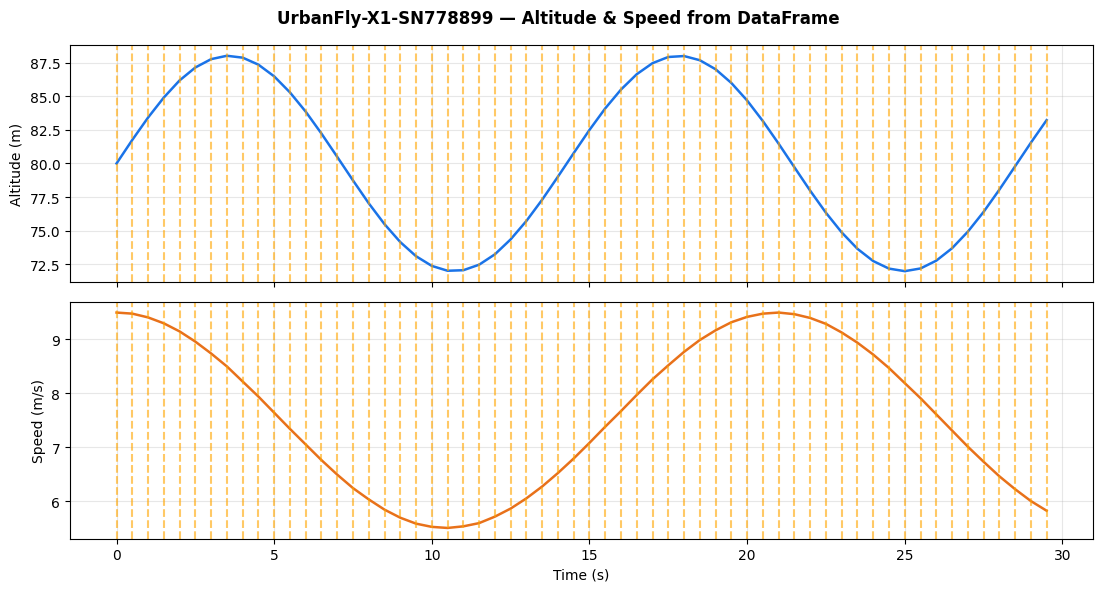

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(df['t'], df['alt_m'],    color='#1a73e8', linewidth=1.8)
axes[0].set_ylabel('Altitude (m)');  axes[0].grid(alpha=0.3)

axes[1].plot(df['t'], df['speed_ms'], color='#e8711a', linewidth=1.8)
axes[1].set_ylabel('Speed (m/s)');   axes[1].set_xlabel('Time (s)');  axes[1].grid(alpha=0.3)

# Mark events
for _, row in df_ev[df_ev['event_type'].notna()].iterrows():
    for ax in axes:
        ax.axvline(row['t'], color='orange', linestyle='--', alpha=0.6)

fig.suptitle(f"{mfx.meta.drone_id} — Altitude & Speed from DataFrame", fontweight='bold')
fig.tight_layout()
plt.show()

## 3. JSON serialisation

`mfx.to_dict()` converts the entire `MfxFile` (all nested dataclasses) to a plain Python `dict`.
`mfx.to_json()` returns a JSON string.

In [10]:
d = mfx.to_dict()

print("Top-level keys:", list(d.keys()))
print("Meta keys     :", list(d['meta'].keys()))
print("First point   :", d['trajectory']['points'][0])

Top-level keys: ['version', 'encoding', 'meta', 'trajectory', 'events', 'index', 'extensions']
Meta keys     : ['id', 'drone_id', 'drone_type', 'pilot_id', 'date_start', 'status', 'application', 'location', 'sensors', 'data_level', 'license', 'contact', 'manufacturer', 'date_end', 'duration_s', 'crs', 'altitude_ref', 'processing_tools', 'producer', 'producer_version', 'source_format', 'source_format_detail', 'extra']
First point   : {'t': 0.0, 'lat': 48.8566, 'lon': 2.3522, 'alt_m': 80.0, 'speed_ms': 9.5, 'heading': 0, 'roll': None, 'pitch': None, 'extra': {}}


In [11]:
json_str = mfx.to_json(indent=2)

# Preview
print(json_str[:500], "...")

{
  "version": "1.0",
  "encoding": "UTF-8",
  "meta": {
    "id": "uuid:857db43b-1aa6-4bce-a633-1a8e07b6ae9f",
    "drone_id": "UrbanFly-X1-SN778899",
    "drone_type": "multirotor",
    "pilot_id": "FR-PILOT-2024",
    "date_start": "2026-09-01T14:00:00Z",
    "status": "complete",
    "application": "delivery",
    "location": "Paris, France",
    "sensors": [
      "rgb",
      "lidar"
    ],
    "data_level": "raw",
    "license": "CC-BY-4.0",
    "contact": "ops@urbanfly.fr",
    "manufact ...


In [12]:
# Round-trip: JSON → dict → check values
reloaded = json.loads(json_str)
assert reloaded['meta']['drone_id'] == mfx.meta.drone_id
assert len(reloaded['trajectory']['points']) == N
print("Round-trip JSON ✓")

Round-trip JSON ✓


In [13]:
# Save as JSON
with open('/tmp/flight_export.json', 'w') as f:
    f.write(json_str)
print(f"Saved {len(json_str):,} characters to /tmp/flight_export.json")

Saved 20,596 characters to /tmp/flight_export.json


## Summary

| Feature | Function | Returns | Extra dep |
|---|---|---|---|
| Aggregated metrics | `pymfx.flight_stats(mfx)` | `FlightStats` | none |
| Trajectory DataFrame | `mfx.trajectory.to_dataframe()` | `pd.DataFrame` | pandas |
| DataFrame + events | `mfx.trajectory.to_dataframe(events=mfx.events)` | `pd.DataFrame` | pandas |
| Dict serialisation | `mfx.to_dict()` | `dict` | none |
| JSON serialisation | `mfx.to_json(indent=2)` | `str` | none |